# Retail Sales Exploratory Data Analysis

## Project Objective
This project analyzes customer shopping behavior using Python to identify sales trends, customer demographics, product category performance, and business insights through Exploratory Data Analysis (EDA).

## Dataset
- Source: Kaggle
- Records: 99,458
- Features: 10

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use("ggplot")
sns.set(font_scale=1.0)
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

The dataset is loaded into a Pandas DataFrame for further analysis.

In [3]:
df = pd.read_csv("customer_shopping_dataset.csv")

## Initial Data Inspection

This section examines the dataset structure, data types, dimensions, missing values, duplicates, and summary statistics.

In [32]:
df.head()
df.info()
df.shape
df.columns
df.isnull().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  object        
 1   customer_id     99457 non-null  object        
 2   gender          99457 non-null  object        
 3   age             99457 non-null  int64         
 4   category        99457 non-null  object        
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   payment_method  99457 non-null  object        
 8   invoice_date    99457 non-null  datetime64[ns]
 9   shopping_mall   99457 non-null  object        
 10  Revenue         99457 non-null  float64       
 11  Month           99457 non-null  object        
 12  Quarter         99457 non-null  int32         
 13  Year            99457 non-null  int32         
 14  Day             99457 non-null  object        
 15  Ag

,age,quantity,price,invoice_date,Revenue,Quarter,Year
count,99457.000000,99457.000000,99457.000000,99457,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321,2022-02-04 02:46:59.783424,2528.789268,2.382668,2021.629408
min,18.000000,1.000000,5.230000,2021-01-01 00:00:00,5.230000,1.000000,2021.000000
25%,30.000000,2.000000,45.450000,2021-07-19 00:00:00,136.350000,1.000000,2021.000000
50%,43.000000,3.000000,203.300000,2022-02-05 00:00:00,600.170000,2.000000,2022.000000
75%,56.000000,4.000000,1200.320000,2022-08-22 00:00:00,2700.720000,3.000000,2022.000000
max,69.000000,5.000000,5250.000000,2023-03-08 00:00:00,26250.000000,4.000000,2023.000000
std,14.990054,1.413025,941.184567,NaN,4222.475781,1.148331,0.636136


### Observation

- The dataset contains approximately 99,000 customer transactions.
- No missing values were observed.
- Data types are mostly appropriate, though the date column requires conversion to datetime format.
- No duplicate records were found.

## Data Cleaning

The dataset is prepared for analysis by converting date columns into datetime format and creating new features required for business analysis.

In [7]:
df['invoice_date'] = pd.to_datetime(
    df['invoice_date'],
    format='%d-%m-%Y'
)

In [8]:
df['Revenue'] = df['price'] * df['quantity']

In [9]:
df.dtypes

invoice_no                object
customer_id               object
gender                    object
age                        int64
category                  object
quantity                   int64
price                    float64
payment_method            object
invoice_date      datetime64[ns]
shopping_mall             object
Revenue                  float64
dtype: object

In [11]:
df.mean(numeric_only=True)
df.median(numeric_only=True)
df.mode().iloc[0]
df.std(numeric_only=True)

age           14.990054
quantity       1.413025
price        941.184567
Revenue     4222.475781
dtype: float64

## Feature Engineering

Additional features are extracted from the invoice date to support time-series analysis.

In [33]:
df["Year"] = df["invoice_date"].dt.year
df["Month"] = df["invoice_date"].dt.month_name()
df["Quarter"] = df["invoice_date"].dt.quarter
df["Day"] = df["invoice_date"].dt.day_name()

In [34]:
bins=[0,18,25,35,45,55,100]
labels=[
'0-18',
'19-25',
'26-35',
'36-45',
'46-55',
'55+'
]
df['Age Group']=pd.cut(df['age'], bins=bins, labels=labels)

## Descriptive Statistics

Summary statistics provide an overview of the distribution of numerical variables.

In [35]:
df.describe()

,age,quantity,price,invoice_date,Revenue,Quarter,Year
count,99457.000000,99457.000000,99457.000000,99457,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321,2022-02-04 02:46:59.783424,2528.789268,2.382668,2021.629408
min,18.000000,1.000000,5.230000,2021-01-01 00:00:00,5.230000,1.000000,2021.000000
25%,30.000000,2.000000,45.450000,2021-07-19 00:00:00,136.350000,1.000000,2021.000000
50%,43.000000,3.000000,203.300000,2022-02-05 00:00:00,600.170000,2.000000,2022.000000
75%,56.000000,4.000000,1200.320000,2022-08-22 00:00:00,2700.720000,3.000000,2022.000000
max,69.000000,5.000000,5250.000000,2023-03-08 00:00:00,26250.000000,4.000000,2023.000000
std,14.990054,1.413025,941.184567,NaN,4222.475781,1.148331,0.636136


In [36]:
df.median(numeric_only=True)
df.mode().iloc[0]
df.std(numeric_only=True)

age           14.990054
quantity       1.413025
price        941.184567
Revenue     4222.475781
Quarter        1.148331
Year           0.636136
dtype: float64

## Monthly Revenue Trend

This analysis examines how revenue changes over different months.

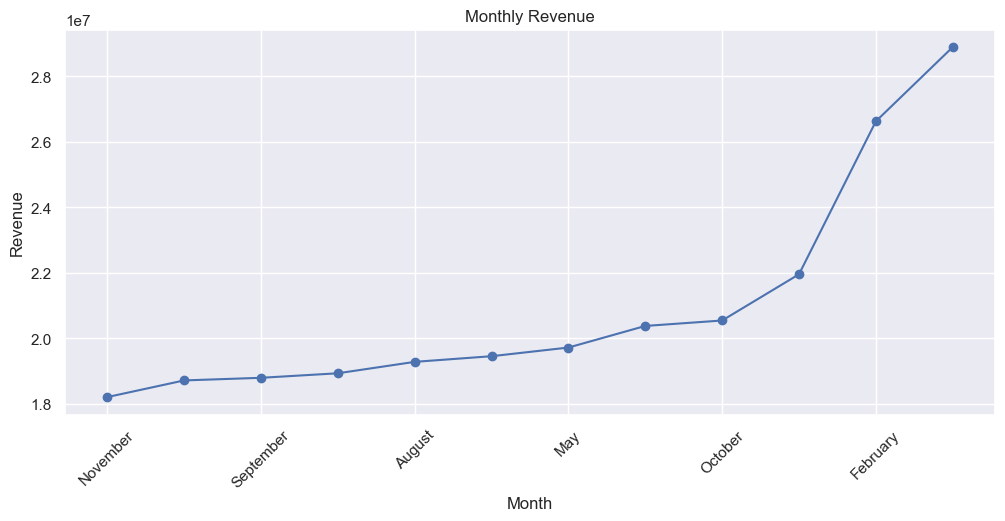

In [37]:
monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
      .sort_values()
)
plt.figure(figsize=(12,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### Observation

- Identify months with the highest and lowest revenue.
- Observe seasonal purchasing patterns.
- Highlight possible reasons for revenue fluctuations.

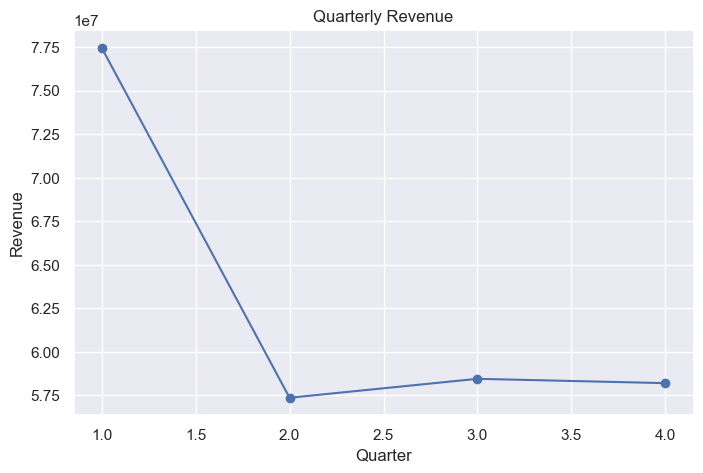

In [38]:
quarter_sales = df.groupby("Quarter")["Revenue"].sum()
plt.figure(figsize=(8,5))
quarter_sales.plot(marker="o")
plt.title("Quarterly Revenue")
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.show()

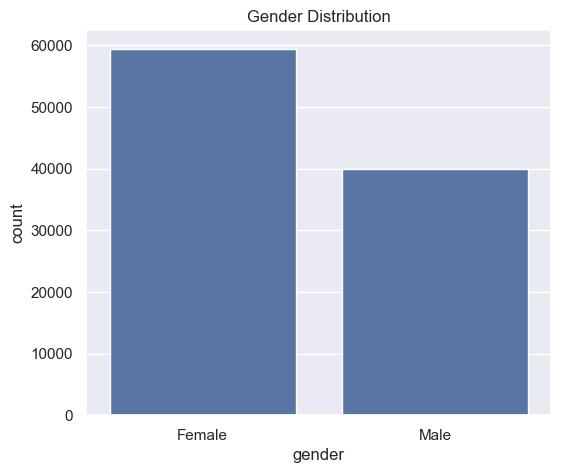

In [39]:
plt.figure(figsize=(6,5))
sns.countplot(data=df,x="gender")
plt.title("Gender Distribution")
plt.show()

### Observation

Discuss which gender contributes more transactions and possible marketing implications.

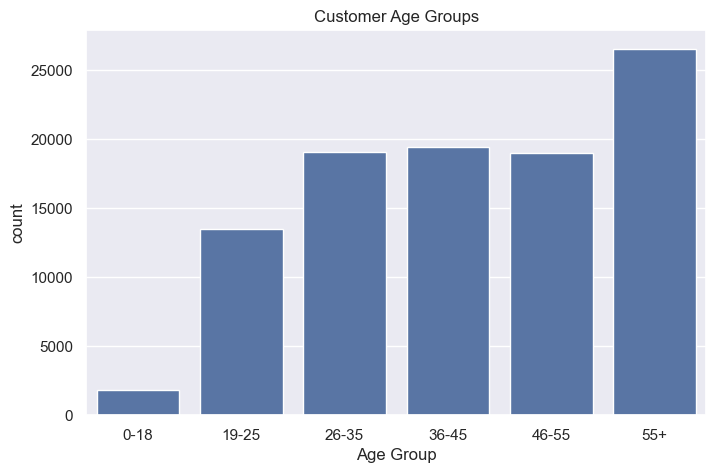

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Age Group")
plt.title("Customer Age Groups")
plt.show()

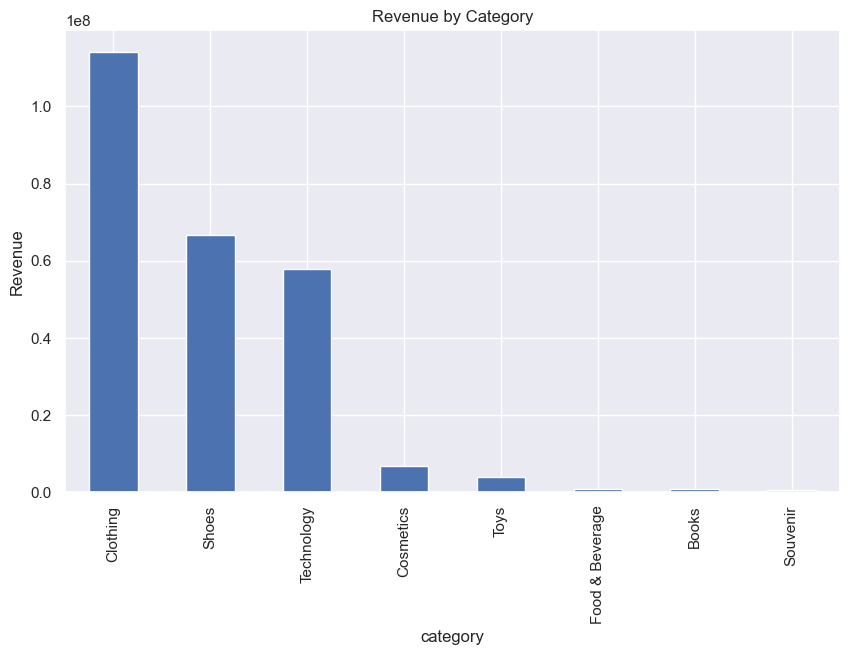

In [41]:
category_sales = (
    df.groupby("category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)
plt.figure(figsize=(10,6))
category_sales.plot(kind="bar")
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

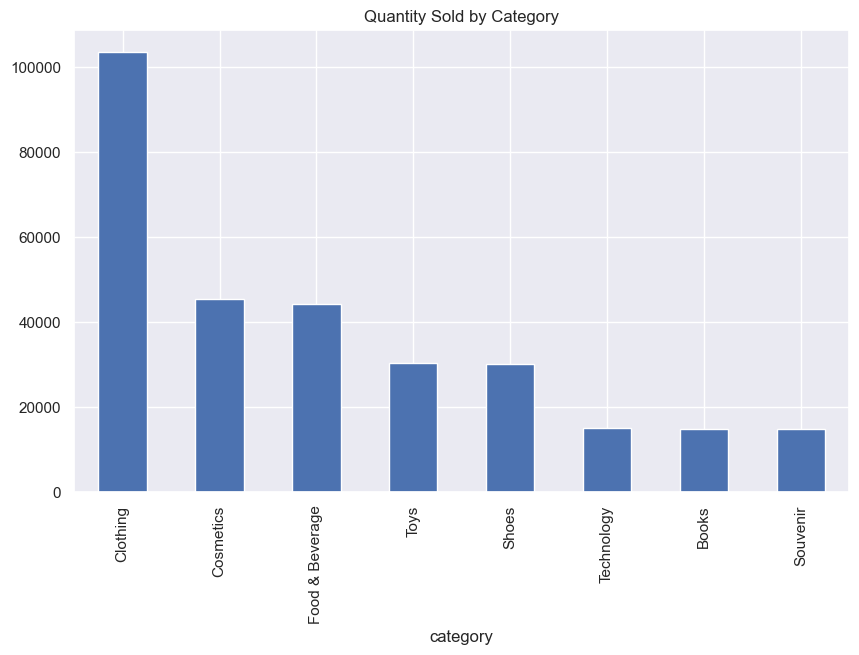

In [42]:
category_quantity = (
    df.groupby("category")["quantity"]
      .sum()
      .sort_values(ascending=False)
)
plt.figure(figsize=(10,6))
category_quantity.plot(kind="bar")
plt.title("Quantity Sold by Category")
plt.show()

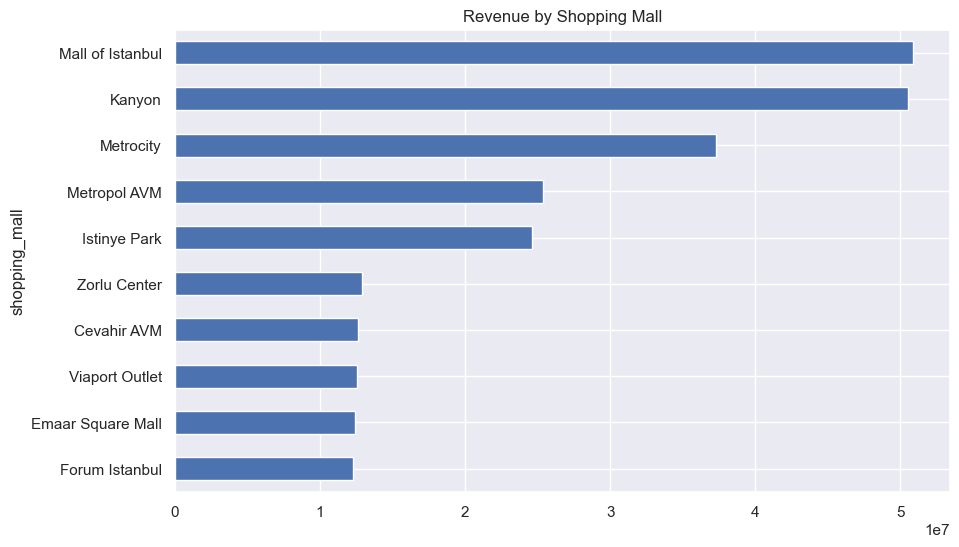

In [43]:
mall_sales = (
    df.groupby("shopping_mall")["Revenue"]
      .sum()
      .sort_values()
)
plt.figure(figsize=(10,6))
mall_sales.plot(kind="barh")
plt.title("Revenue by Shopping Mall")
plt.show()

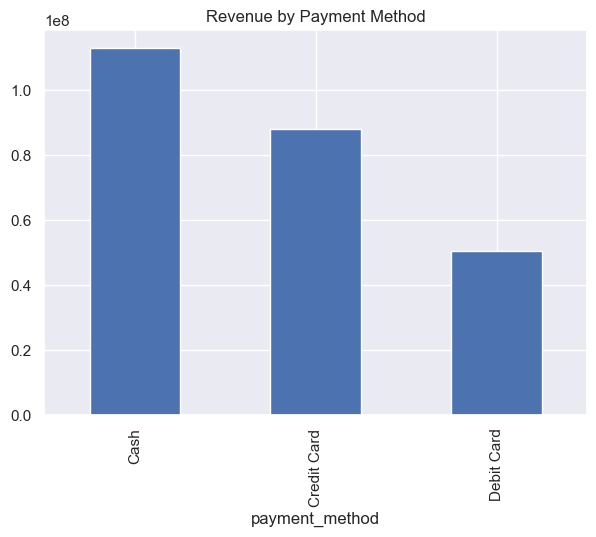

In [44]:
payment = (
    df.groupby("payment_method")["Revenue"]
      .sum()
)
plt.figure(figsize=(7,5))
payment.plot(kind="bar")
plt.title("Revenue by Payment Method")
plt.show()

## Correlation Analysis

The correlation heatmap helps identify relationships between numerical variables.

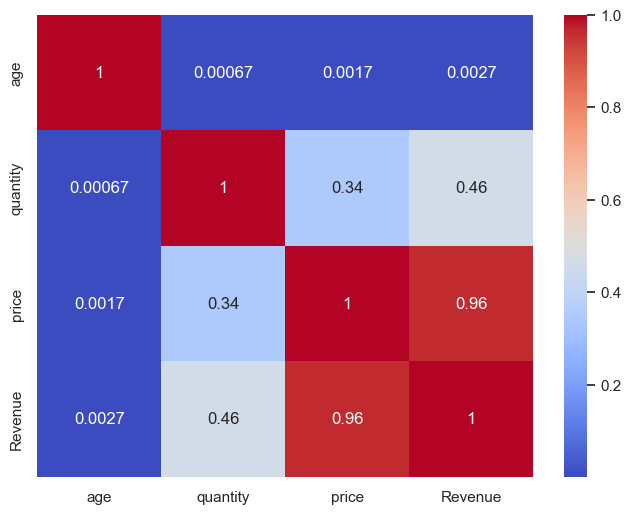

In [45]:
plt.figure(figsize=(8,6))
corr = df[
    ["age","quantity","price","Revenue"]
].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.show()

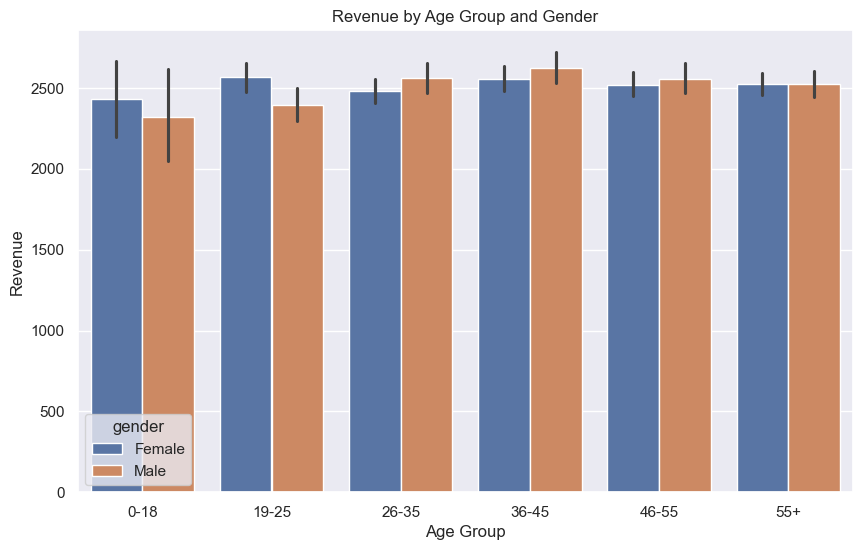

In [46]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="Age Group",
    y="Revenue",
    hue="gender"
)
plt.title("Revenue by Age Group and Gender")
plt.show()

# Key Findings

- Summarize the most important insights discovered during the analysis.
- Mention customer demographics, sales trends, and product performance.
- Highlight any interesting relationships between variables.

# Business Recommendations

1. Increase inventory for high-performing product categories.

2. Target marketing campaigns toward the most active customer age groups.

3. Improve sales performance in underperforming shopping malls.

4. Promote preferred payment methods using cashback or discount offers.

5. Develop promotional bundles by combining high-demand and premium products.

# Conclusion

This Exploratory Data Analysis provided valuable insights into customer purchasing behavior, product category performance, revenue trends, and shopping mall sales. The findings can support better inventory management, targeted marketing strategies, and informed business decision-making.

## Limitations

- The dataset contains product categories rather than individual product names.
- Therefore, product-level analysis (such as Top 10 Best-Selling Products) could not be performed.
- Category-level analysis was used instead to provide meaningful business insights.